<div style="background-color:#118AB2; padding: 18px; border-radius: 3px; text-align:center; font-size:2.5em; font-weight:bold; color:#222; margin-bottom:25px; letter-spacing:1px;">
Predicting Donor Response for Social Good 
</div>

# <h2 style="border-bottom: 4px solid #118AB2; width:fit-content; margin: 0 auto 25px auto; padding-bottom:6px; font-weight:bold;">Model Selection</h2>

_Data Mining II 2025/2026_

Project by:
Francisco Gomes (20221810), Margarida Marchão (20221901), Marta Alves (20221890), Pedro Coimbras (20211573)


## <h3 style="border-bottom: 4px solid #118AB2; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">1. Imports and data loading</h3>

This notebook makes use of the previously transformed and processed datasets to train and evaluate different prediction models.


In [57]:
"""Importing the libraries needed for data handling, preprocessing, modeling, and evaluation"""
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from IPython.display import display
import optuna
from sklearn.exceptions import ConvergenceWarning

"""Adding the project root to the Python path so notebook imports work correctly"""
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress the output for each trial optuna
#warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")  # Run to remove warnings
#warnings.resetwarnings()  # Run to add warnings


In [58]:
"""Loading the features datasets"""
train_data = pd.read_csv(PROJECT_ROOT / "project_data" / "X_train_clean.csv", index_col=0)
val_data = pd.read_csv(PROJECT_ROOT / "project_data" / "X_val_clean.csv", index_col=0)
test_data = pd.read_csv(PROJECT_ROOT / "project_data" / "X_test_clean.csv", index_col=0)

'''Loading the y datasets'''
y_train = pd.read_csv(PROJECT_ROOT / "project_data" / "y_train_clean.csv")
y_val = pd.read_csv(PROJECT_ROOT / "project_data" / "y_val_clean.csv")
y_test = pd.read_csv(PROJECT_ROOT / "project_data" / "donors_test.csv")



## <h3 style="border-bottom: 4px solid #118AB2; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">2. Defining Hyper-Parameter Tuner</h3>

Defining the Optuna based Hyper-Parameter Tuner 

In [59]:
# Lists to plot the model comparison
best_scores_train = []
best_scores_val = []

# Lists to store scores for each trial
training_scores = []
val_scores = []

# Define the objective function using explicit train/validation evaluation
def objective(trial, model_type):
    if model_type == 'GradientBoosting':
        # Define hyperparameters to be optimized for GradientBoosting
        n_estimators = trial.suggest_int("n_estimators", 2, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 1.0, log=True)
        subsample = trial.suggest_float("subsample", 0.2, 1.0)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 6)
        max_features = trial.suggest_categorical("max_features", [2, 0.5, 'sqrt', 'log2', None])
        max_depth = trial.suggest_int("max_depth", 2, 6)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 4)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            subsample=subsample,
            max_features=max_features,
            max_leaf_nodes=max_leaf_nodes,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=1,
        )

    elif model_type == 'LogisticRegression':
        C = trial.suggest_float('C', 0.001, 200)
        solver = trial.suggest_categorical('solver', ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'])
        max_iter = trial.suggest_int('max_iter', 100, 1000)
        fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])

        model = LogisticRegression(
            C=C,
            solver=solver,
            max_iter=max_iter,
            fit_intercept=fit_intercept,
            random_state=1,
        )

    elif model_type == 'AdaBoost':
        estimator = DecisionTreeClassifier(
            max_depth=trial.suggest_int("max_depth", 1, 6),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 8),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
            random_state=1,
        )

        n_estimators = trial.suggest_int("n_estimators", 2, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 1.0, log=True)
        algorithm = trial.suggest_categorical('algorithm', ["SAMME", "SAMME.R"])

        model = AdaBoostClassifier(
            estimator=estimator,
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            algorithm=algorithm,
            random_state=14,
        )

    elif model_type == 'DecisionTree':
        max_depth = trial.suggest_int("max_depth", 3, 7)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 10, 15)

        model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=1,
        )

    elif model_type == 'RandomForestClassifier':
        n_estimators = trial.suggest_int('n_estimators', 7, 25)
        criterion = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])
        max_depth = trial.suggest_int('max_depth', 10, 14)
        min_samples_split = trial.suggest_int('min_samples_split', 5, 14)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 11)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])
        warm_start = trial.suggest_categorical('warm_start', [True, False])
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
        max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 10, 120)
        min_weight_fraction_leaf = trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5)

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            criterion=criterion,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=1,
            max_leaf_nodes=max_leaf_nodes,
            min_weight_fraction_leaf=min_weight_fraction_leaf,
            bootstrap=bootstrap,
            warm_start=warm_start,
            max_features=max_features,
        )

    elif model_type == 'GaussianNB':
        var_smoothing = trial.suggest_int('var_smoothing', -12, -6)
        model = GaussianNB(var_smoothing=10 ** var_smoothing)

    elif model_type == 'KNeighborsClassifier':
        n_neighbors = trial.suggest_int('n_neighbors', 1, 50)
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        algorithm = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])
        leaf_size = trial.suggest_int('leaf_size', 10, 100)
        p = trial.suggest_int('p', 1, 6)

        model = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            algorithm=algorithm,
            leaf_size=leaf_size,
            p=p,
        )

    elif model_type == 'MLPClassifier':
        activation = trial.suggest_categorical('activation', ['identity', 'logistic', 'tanh', 'relu'])
        solver = trial.suggest_categorical('solver', ['lbfgs', 'sgd', 'adam'])
        learning_rate = trial.suggest_categorical('learning_rate', ['constant', 'invscaling', 'adaptive'])
        shuffle = trial.suggest_categorical('shuffle', [True, False])
        early_stopping = trial.suggest_categorical('early_stopping', [True, False])
        max_iter = trial.suggest_int('max_iter', 100, 1000)

        model = MLPClassifier(
            activation=activation,
            solver=solver,
            learning_rate=learning_rate,
            shuffle=shuffle,
            early_stopping=early_stopping,
            max_iter=max_iter,
        )

    elif model_type == 'Stacking':
        rf_params = {
            'n_estimators': 16,
            'criterion': 'log_loss',
            'max_depth': 10,
            'min_samples_split': 7,
            'min_samples_leaf': 6,
            'bootstrap': False,
            'warm_start': False,
        }
        DTC_params = {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 11}
        lr_params = {'C': 13.201220684960449, 'solver': 'newton-cg', 'max_iter': 419, 'fit_intercept': True}
        KNN_params = {'n_neighbors': 27, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 55, 'p': 2}

        meta_model_choice = trial.suggest_categorical('final_estimator', ['KNN', 'LogisticRegression'])
        if meta_model_choice == 'LogisticRegression':
            meta_model = LogisticRegression(**lr_params)
        else:
            meta_model = KNeighborsClassifier(**KNN_params)

        model = StackingClassifier(
            estimators=[
                ('LogisticRegression', LogisticRegression(**lr_params)),
                ('DecisionTreeClassifier', DecisionTreeClassifier(**DTC_params)),
                ('RandomF', RandomForestClassifier(**rf_params)),
            ],
            final_estimator=meta_model,
        )

    else:
        raise ValueError("Invalid model_type.")

    # Train on the training split and evaluate on validation split
    model.fit(train_data, y_train)
    train_preds = model.predict(train_data)
    val_preds = model.predict(val_data)

    training_score = f1_score(y_train, train_preds)
    validation_score = f1_score(y_val, val_preds)

    training_scores.append(training_score)
    val_scores.append(validation_score)

    return validation_score

In [60]:
# Define the optimization function
def optimize_with_optuna(model_type, n_trials=100, hyper_importance=False, slice_plot=False, optimization_history=False):
    # Create an Optuna study
    study = optuna.create_study(direction="maximize")

    # Optimize the study with a specified number of trials and set verbose=False
    study.optimize(lambda trial: objective(trial, model_type), n_trials=n_trials)

       # Print the results of the optimization
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    trial = study.best_trial
    print("  Validation Score (F1): ", trial.value)  # Validation score for the best trial
    print("  Train Score (F1): ", training_scores[trial.number])  # Training score for the best trial
    print("  Params: ", study.best_params)

    # Plot the evolution of scores
    plt.plot(training_scores, label='Training Score (F1)')
    plt.plot(val_scores, label='Validation Score (F1)')
    plt.xlabel('Trials')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.show()

    if hyper_importance:
        display(optuna.visualization.plot_param_importances(study))

    if slice_plot:
        params_to_plot = study.best_params.keys()
        display(optuna.visualization.plot_slice(study, params=params_to_plot))

    if optimization_history:
        display(optuna.visualization.plot_optimization_history(study))


## <h3 style="border-bottom: 4px solid #118AB2; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">3. Defining Models</h3>

Defining standalone models

In [61]:
# Define model-specific optimization wrappers using the shared optimize_with_optuna helper.
# These wrappers make it easy to run the same tuner for each model from the section below.

def optimize_gradient_boosting(n_trials=100, **kwargs):
    return optimize_with_optuna("GradientBoosting", n_trials=n_trials, **kwargs)


def optimize_logistic_regression(n_trials=100, **kwargs):
    return optimize_with_optuna("LogisticRegression", n_trials=n_trials, **kwargs)


def optimize_adaboost(n_trials=100, **kwargs):
    return optimize_with_optuna("AdaBoost", n_trials=n_trials, **kwargs)


def optimize_decision_tree(n_trials=100, **kwargs):
    return optimize_with_optuna("DecisionTree", n_trials=n_trials, **kwargs)


def optimize_random_forest(n_trials=100, **kwargs):
    return optimize_with_optuna("RandomForestClassifier", n_trials=n_trials, **kwargs)


def optimize_gaussian_nb(n_trials=100, **kwargs):
    return optimize_with_optuna("GaussianNB", n_trials=n_trials, **kwargs)


def optimize_knn(n_trials=100, **kwargs):
    return optimize_with_optuna("KNeighborsClassifier", n_trials=n_trials, **kwargs)


def optimize_mlp(n_trials=100, **kwargs):
    return optimize_with_optuna("MLPClassifier", n_trials=n_trials, **kwargs)


def optimize_stacking(n_trials=100, **kwargs):
    return optimize_with_optuna("Stacking", n_trials=n_trials, **kwargs)

model_optimizers = {
    "GradientBoosting": optimize_gradient_boosting,
    "LogisticRegression": optimize_logistic_regression,
    "AdaBoost": optimize_adaboost,
    "DecisionTree": optimize_decision_tree,
    "RandomForestClassifier": optimize_random_forest,
    "GaussianNB": optimize_gaussian_nb,
    "KNeighborsClassifier": optimize_knn,
    "MLPClassifier": optimize_mlp,
    "Stacking": optimize_stacking,
}

print("Defined model optimization wrappers for:", ", ".join(model_optimizers.keys()))

Defined model optimization wrappers for: GradientBoosting, LogisticRegression, AdaBoost, DecisionTree, RandomForestClassifier, GaussianNB, KNeighborsClassifier, MLPClassifier, Stacking


## <h3 style="border-bottom: 4px solid #118AB2; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">4. Training and Evaluating Models</h3>

Training and tuning the previously defined models

## <h3 style="border-bottom: 4px solid #118AB2; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">5. Model Selection</h3>



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5: Hyperparameter Tuning with Optuna
# ─────────────────────────────────────────────────────────────────────────────

import optuna
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import f1_score
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Storage for trial scores — reset before each optimize_with_optuna() call
training_scores = []
val_scores      = []


# ─────────────────────────────────────────────────────────────────────────────
# Objective — train on X_train / y_train, evaluate on X_val / y_val
# No cross-validation: a single fit/predict per trial is enough because
# you already have a held-out validation set.
# ─────────────────────────────────────────────────────────────────────────────
def objective(trial, model_type):

    # ── model definitions ────────────────────────────────────────────────────
    if model_type == 'GradientBoosting':
        model = GradientBoostingClassifier(
            n_estimators      = trial.suggest_int("n_estimators", 2, 500),
            learning_rate     = trial.suggest_float("learning_rate", 0.001, 1.0, log=True),
            subsample         = trial.suggest_float("subsample", 0.2, 1.0),
            max_features      = trial.suggest_categorical("max_features", [2, 0.5, 'sqrt', 'log2', None]),
            max_leaf_nodes    = trial.suggest_int("max_leaf_nodes", 2, 6),
            max_depth         = trial.suggest_int("max_depth", 2, 6),
            min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
            min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 4),
            random_state      = 1,
        )

    elif model_type == 'LogisticRegression':
        model = LogisticRegression(
            C             = trial.suggest_float('C', 0.001, 200),
            solver        = trial.suggest_categorical('solver', ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']),
            max_iter      = trial.suggest_int('max_iter', 100, 1000),
            fit_intercept = trial.suggest_categorical('fit_intercept', [True, False]),
        )

    elif model_type == 'AdaBoost':
        base = DecisionTreeClassifier(
            max_depth         = trial.suggest_int("max_depth", 1, 6),
            min_samples_split = trial.suggest_int("min_samples_split", 2, 8),
            min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 8),
        )
        model = AdaBoostClassifier(
            estimator     = base,
            n_estimators  = trial.suggest_int("n_estimators", 2, 500),
            learning_rate = trial.suggest_float("learning_rate", 0.001, 1.0, log=True),
            algorithm     = trial.suggest_categorical('algorithm', ["SAMME"]),
            random_state  = 14,
        )

    elif model_type == 'DecisionTree':
        model = DecisionTreeClassifier(
            criterion            = trial.suggest_categorical('criterion', ['gini', 'entropy']),
            max_depth            = trial.suggest_int("max_depth", 3, 7),
            min_samples_split    = trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf     = trial.suggest_int('min_samples_leaf', 10, 15),
            splitter             = trial.suggest_categorical('splitter', ['best', 'random']),
            max_features         = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
            max_leaf_nodes       = trial.suggest_int('max_leaf_nodes', 40, 50),
            min_impurity_decrease= trial.suggest_float('min_impurity_decrease', 0.0, 0.1, step=0.01),
            random_state         = 1,
        )

    elif model_type == 'RandomForestClassifier':
        model = RandomForestClassifier(
            n_estimators              = trial.suggest_int('n_estimators', 7, 25),
            criterion                 = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
            max_depth                 = trial.suggest_int('max_depth', 10, 14),
            min_samples_split         = trial.suggest_int('min_samples_split', 5, 14),
            min_samples_leaf          = trial.suggest_int('min_samples_leaf', 1, 11),
            bootstrap                 = trial.suggest_categorical('bootstrap', [True, False]),
            warm_start                = trial.suggest_categorical('warm_start', [True, False]),
            max_features              = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            max_leaf_nodes            = trial.suggest_int('max_leaf_nodes', 10, 120),
            min_weight_fraction_leaf  = trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5),
            random_state              = 1,
        )

    elif model_type == 'GaussianNB':
        model = GaussianNB(
            var_smoothing = 10 ** trial.suggest_int('var_smoothing', -12, -6)
        )

    elif model_type == 'KNeighborsClassifier':
        model = KNeighborsClassifier(
            n_neighbors = trial.suggest_int('n_neighbors', 1, 50),
            weights     = trial.suggest_categorical('weights', ['uniform', 'distance']),
            algorithm   = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),
            leaf_size   = trial.suggest_int('leaf_size', 10, 100),
            p           = trial.suggest_int('p', 1, 6),
        )

    elif model_type == 'MLPClassifier':
        model = MLPClassifier(
            activation    = trial.suggest_categorical('activation', ['identity', 'logistic', 'tanh', 'relu']),
            solver        = trial.suggest_categorical('solver', ['lbfgs', 'sgd', 'adam']),
            learning_rate = trial.suggest_categorical('learning_rate', ['constant', 'invscaling', 'adaptive']),
            shuffle       = trial.suggest_categorical('shuffle', [True, False]),
            early_stopping= trial.suggest_categorical('early_stopping', [True, False]),
            max_iter      = trial.suggest_int('max_iter', 100, 1000),
        )

    elif model_type == 'Stacking':
        # Best params found in previous individual tuning runs
        lr_params       = {'C': 13.201220684960449, 'solver': 'newton-cg', 'max_iter': 419, 'fit_intercept': True}
        dtc_params      = {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 11}
        rf_params       = {'n_estimators': 16, 'criterion': 'log_loss', 'max_depth': 10,
                           'min_samples_split': 7, 'min_samples_leaf': 6, 'bootstrap': False, 'warm_start': False}
        knn_params      = {'n_neighbors': 27, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 55, 'p': 2}

        meta_choice = trial.suggest_categorical('final_estimator', ['KNN', 'LogisticRegression'])
        meta_model  = (LogisticRegression(**lr_params)
                       if meta_choice == 'LogisticRegression'
                       else KNeighborsClassifier(**knn_params))

        model = StackingClassifier(
            estimators=[
                ('lr',  LogisticRegression(**lr_params)),
                ('dtc', DecisionTreeClassifier(**dtc_params)),
                ('rf',  RandomForestClassifier(**rf_params)),
            ],
            final_estimator=meta_model,
        )

    else:
        raise ValueError(f"Unknown model_type '{model_type}'.")

    # ── fit on train, score on val ───────────────────────────────────────────
    model.fit(train_data, y_train.values.ravel())

    train_f1 = f1_score(y_train, model.predict(train_data), average='binary')
    val_f1   = f1_score(y_val,   model.predict(val_data),   average='binary')

    training_scores.append(train_f1)
    val_scores.append(val_f1)

    return val_f1


# ─────────────────────────────────────────────────────────────────────────────
# Optimization runner
# ─────────────────────────────────────────────────────────────────────────────
def optimize_with_optuna(
    model_type,
    n_trials=100,
    hyper_importance=False,
    slice_plot=False,
    optimization_history=False,
):
    global training_scores, val_scores
    training_scores, val_scores = [], []

    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, model_type), n_trials=n_trials)

    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    print(f"Finished trials  : {len(study.trials)}")
    print(f"Completed trials : {len(completed)}")

    if not completed:
        print("No trials completed successfully — skipping results.")
        return study

    best = study.best_trial
    print(f"Best trial       : #{best.number}")
    print(f"  Val F1         : {best.value:.4f}")
    print(f"  Train F1       : {training_scores[best.number]:.4f}")
    print(f"  Params         : {study.best_params}")

    # Score evolution plot
    plt.figure(figsize=(10, 4))
    plt.plot(training_scores, label='Train F1')
    plt.plot(val_scores,      label='Validation F1')
    plt.xlabel('Trial')
    plt.ylabel('F1 Score')
    plt.title(f'Optuna – {model_type}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    if hyper_importance:
        try:
            display(optuna.visualization.plot_param_importances(study))
        except RuntimeError as e:
            print(f"[hyper_importance] Skipped — {e}")

    if slice_plot:
        try:
            display(optuna.visualization.plot_slice(study, params=list(study.best_params.keys())))
        except RuntimeError as e:
            print(f"[slice_plot] Skipped — {e}")

    if optimization_history:
        try:
            display(optuna.visualization.plot_optimization_history(study))
        except RuntimeError as e:
            print(f"[optimization_history] Skipped — {e}")

    return study

# ─────────────────────────────────────────────────────────────────────────────
# Individual models
# ─────────────────────────────────────────────────────────────────────────────
'''study_lr  = optimize_with_optuna('LogisticRegression',    n_trials=150, hyper_importance=True, slice_plot=True, optimization_history=True)
study_dt  = optimize_with_optuna('DecisionTree',          n_trials=200, hyper_importance=True, slice_plot=True, optimization_history=True)
study_nb  = optimize_with_optuna('GaussianNB',            n_trials=200, hyper_importance=True, slice_plot=True, optimization_history=True)
study_knn = optimize_with_optuna('KNeighborsClassifier',  n_trials=200, hyper_importance=True, slice_plot=True, optimization_history=True)
study_mlp = optimize_with_optuna('MLPClassifier',         n_trials=200, hyper_importance=True, slice_plot=True, optimization_history=True)

# ─────────────────────────────────────────────────────────────────────────────
# Ensemble models
# ─────────────────────────────────────────────────────────────────────────────
study_rf  = optimize_with_optuna('RandomForestClassifier', n_trials=400, hyper_importance=True, slice_plot=True, optimization_history=True)
study_gb  = optimize_with_optuna('GradientBoosting',       n_trials=200, hyper_importance=True, slice_plot=True, optimization_history=True)
study_ada = optimize_with_optuna('AdaBoost',               n_trials=100, hyper_importance=True, slice_plot=True, optimization_history=True)
study_stk = optimize_with_optuna('Stacking',               n_trials=50,  hyper_importance=True, slice_plot=True, optimization_history=True)'''

"study_lr  = optimize_with_optuna('LogisticRegression',    n_trials=150, hyper_importance=True, slice_plot=True, optimization_history=True)\nstudy_dt  = optimize_with_optuna('DecisionTree',          n_trials=200, hyper_importance=True, slice_plot=True, optimization_history=True)\nstudy_nb  = optimize_with_optuna('GaussianNB',            n_trials=200, hyper_importance=True, slice_plot=True, optimization_history=True)\nstudy_knn = optimize_with_optuna('KNeighborsClassifier',  n_trials=200, hyper_importance=True, slice_plot=True, optimization_history=True)\nstudy_mlp = optimize_with_optuna('MLPClassifier',         n_trials=200, hyper_importance=True, slice_plot=True, optimization_history=True)\n\n# ─────────────────────────────────────────────────────────────────────────────\n# Ensemble models\n# ─────────────────────────────────────────────────────────────────────────────\nstudy_rf  = optimize_with_optuna('RandomForestClassifier', n_trials=400, hyper_importance=True, slice_plot=True, opt

Finished trials : 150
Best trial      : #0
  Val F1        : 0.0000
  Train F1      : 0.0100
  Params        : {'C': 31.506530123935764, 'solver': 'saga', 'max_iter': 833, 'fit_intercept': True}


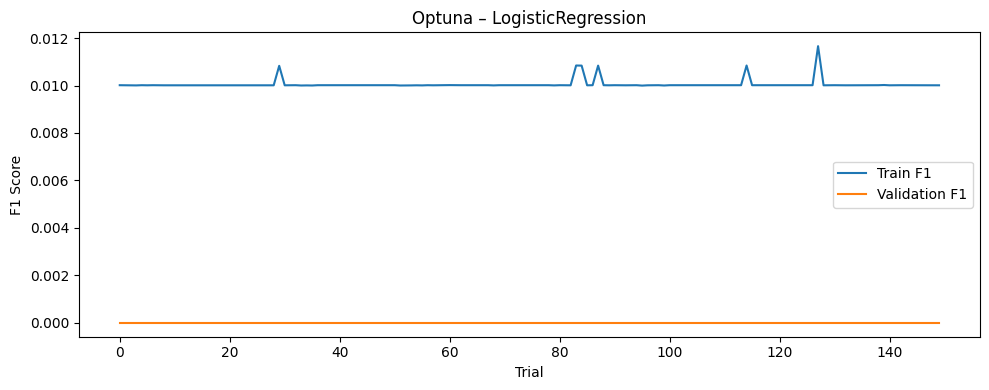

RuntimeError: Encountered zero total variance in all trees.

In [63]:
optimize_with_optuna('LogisticRegression',    n_trials=150, hyper_importance=True, slice_plot=True, optimization_history=True)

In [ ]:
y_train

""
TARGET_B
0
0
0
0
0
...
0
0
0
